In [186]:
from utils.paths import SAMPLING_DIR, RAW_DIR,PREDICTIONS_DIR

In [187]:
import numpy as np
import pandas as pd
import pickle
from models_scripts.AdaptiveTransferKernel import AdaptiveTransferKernel
from sklearn.preprocessing import StandardScaler
from preprocessing.TernaryPlot import plot_ternary_heatmap

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [188]:
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

Experimental data GP - Random splitting

In [189]:
with open(SAMPLING_DIR/"random_split", "rb") as f:
    random_split = pickle.load(f)
    
with open(SAMPLING_DIR/"cluster_split", "rb") as f:
    cluster_split = pickle.load(f)

In [227]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler


def prepare_train_test_data(
    split_dict,
    feature_cols,
    composition_cols=("Cu", "Ni", "Al"),
    standardize=True
):

    feature_cols = list(feature_cols)
    composition_cols = list(composition_cols)

    # Full original split dataframes
    X_train_split_full = split_dict["X_train_split"].copy()
    X_test_split_full = split_dict["X_test_split"].copy()

    # Features for model input
    X_train_df = X_train_split_full[feature_cols].copy()
    X_test_df = X_test_split_full[feature_cols].copy()

    # Composition-only dataframes
    available_comp_cols = [col for col in composition_cols if col in X_train_split_full.columns]
    X_train_composition_df = X_train_split_full[available_comp_cols].copy()
    X_test_composition_df = X_test_split_full[available_comp_cols].copy()

    # Convert feature data to numpy
    X_train = np.asarray(X_train_df, dtype=float)
    X_test = np.asarray(X_test_df, dtype=float)

    y_train = np.asarray(split_dict["y_train"], dtype=float).ravel()
    y_test = np.asarray(split_dict["y_test"], dtype=float).ravel()

    # Standardize only feature columns
    scaler = None
    if standardize:
        scaler = MinMaxScaler()
        X_train_proc = scaler.fit_transform(X_train)
        X_test_proc = scaler.transform(X_test)
    else:
        X_train_proc = X_train.copy()
        X_test_proc = X_test.copy()

    data_dict = {
        "feature_cols": feature_cols,
        "composition_cols": available_comp_cols,
        "standardize": standardize,
        "scaler": scaler,
        
        "X_train_split_full": X_train_split_full,
        "X_test_split_full": X_test_split_full,

        "X_train_df": X_train_df,
        "X_test_df": X_test_df,


        "X_train_composition_df": X_train_composition_df,
        "X_test_composition_df": X_test_composition_df,

        "X_train_proc": X_train_proc,
        "X_test_proc": X_test_proc,

        "y_train": y_train,
        "y_test": y_test,
    }

    return data_dict

In [228]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_and_predict_space(
    model,
    data_dict,
    comp_space,
    feature_cols,
    composition_cols=("Cu", "Ni", "Al"),
    return_std=True,
    save=False,
    save_path=None,
    pred_filename="gp_random_split.pkl",
    pred_col="e2",
    scale_compositions=True
):
    results = {}

    feature_cols = list(feature_cols)
    composition_cols = list(composition_cols)

    # -------------------------
    # test prediction
    # -------------------------
    X_test_proc = data_dict["X_test_proc"]
    y_test = data_dict["y_test"]

    if return_std:
        y_test_pred, std_test_pred = model.predict(X_test_proc, return_std=True)
        results["std_test_pred"] = np.asarray(std_test_pred, dtype=float).ravel()
    else:
        y_test_pred = model.predict(X_test_proc)
        results["std_test_pred"] = None

    results["y_test"] = np.asarray(y_test, dtype=float).ravel()
    results["y_test_pred"] = np.asarray(y_test_pred, dtype=float).ravel()

    # Metrics
    results["mae"] = mean_absolute_error(results["y_test"], results["y_test_pred"])
    results["rmse"] = np.sqrt(mean_squared_error(results["y_test"], results["y_test_pred"]))
    results["r2"] = r2_score(results["y_test"], results["y_test_pred"])

    # Error for each test point
    y_error = results["y_test"] - results["y_test_pred"]
    y_error_abs = np.abs(y_error)
    y_error_sq = y_error ** 2

    results["y_error"] = y_error
    results["y_error_abs"] = y_error_abs
    results["y_error_sq"] = y_error_sq

    # -------------------------
    # full space prediction
    # -------------------------
    X_space = np.asarray(comp_space[feature_cols], dtype=float)
    results["x_space"] = X_space

    if data_dict["standardize"]:
        scaler = data_dict["scaler"]
        X_space_proc = scaler.transform(X_space)
    else:
        X_space_proc = X_space.copy()

    results["X_space_proc"] = X_space_proc

    if return_std:
        y_space_pred, std_space_pred = model.predict(X_space_proc, return_std=True)
        results["std_y_pred"] = np.asarray(std_space_pred, dtype=float).ravel()
    else:
        y_space_pred = model.predict(X_space_proc)
        results["std_y_pred"] = None

    results["y_pred"] = np.asarray(y_space_pred, dtype=float).ravel()

    # -------------------------
    # build all-space dataframe
    # -------------------------
    df_pred = comp_space[composition_cols].copy()

    if scale_compositions:
        for col in composition_cols:
            if col in df_pred.columns:
                df_pred[col] = df_pred[col] * 100

    # optional: keep the feature columns too
    for col in feature_cols:
        if col not in df_pred.columns:
            df_pred[col] = comp_space[col].values

    df_pred[pred_col] = results["y_pred"]

    if results["std_y_pred"] is not None:
        df_pred["std"] = results["std_y_pred"]

    # -------------------------
    # build test dataframe
    # -------------------------
    df_test = data_dict["X_test_split_full"][composition_cols].copy()

    if scale_compositions:
        for col in composition_cols:
            if col in df_test.columns:
                df_test[col] = df_test[col] * 100

    # optional: keep the training features too
    for col in feature_cols:
        if col not in df_test.columns:
            df_test[col] = data_dict["X_test_split_full"][col].values

    df_test["y_test"] = results["y_test"]
    df_test["y_test_pred"] = results["y_test_pred"]
    df_test["y_error"] = y_error
    df_test["y_error_abs"] = y_error_abs
    df_test["y_error_sq"] = y_error_sq

    if results["std_test_pred"] is not None:
        df_test["std_test_pred"] = results["std_test_pred"]

    # -------------------------
    # save dictionary
    # -------------------------
    if save:
        save_path = Path(save_path)

        if save_path.suffix:
            file_path = save_path
            file_path.parent.mkdir(parents=True, exist_ok=True)
        else:
            save_path.mkdir(parents=True, exist_ok=True)
            file_path = save_path / pred_filename

        with open(file_path, "wb") as f:
            pickle.dump(results, f)

        results["saved_to"] = str(file_path)

    return results, df_pred, df_test

In [260]:
feature_cols = ['del_r','VEC','del_EN']
composition_cols = ['Cu','Ni','Al']

data_random = prepare_train_test_data(
    split_dict=random_split,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    standardize=True
)

In [230]:
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
)

gpr_nt_ran = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,   
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_nt_ran.fit(data_random["X_train_proc"], data_random["y_train"])
print("Learned kernel:", gpr_nt_ran.kernel_)

Learned kernel: 0.941**2 * Matern(length_scale=0.5, nu=2.5) + WhiteKernel(noise_level=0.251)


In [231]:
gp_random_split, df_rand_split, df_test_rand = evaluate_and_predict_space(
    model=gpr_nt_ran,
    data_dict=data_random,
    comp_space=comp_space,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    return_std=True,
    save=True,
    save_path=PREDICTIONS_DIR / "GP-Experiments" / "gp_random_split.pkl",
    pred_col="e2"
)

Plots [Predicted plot and erro plot]

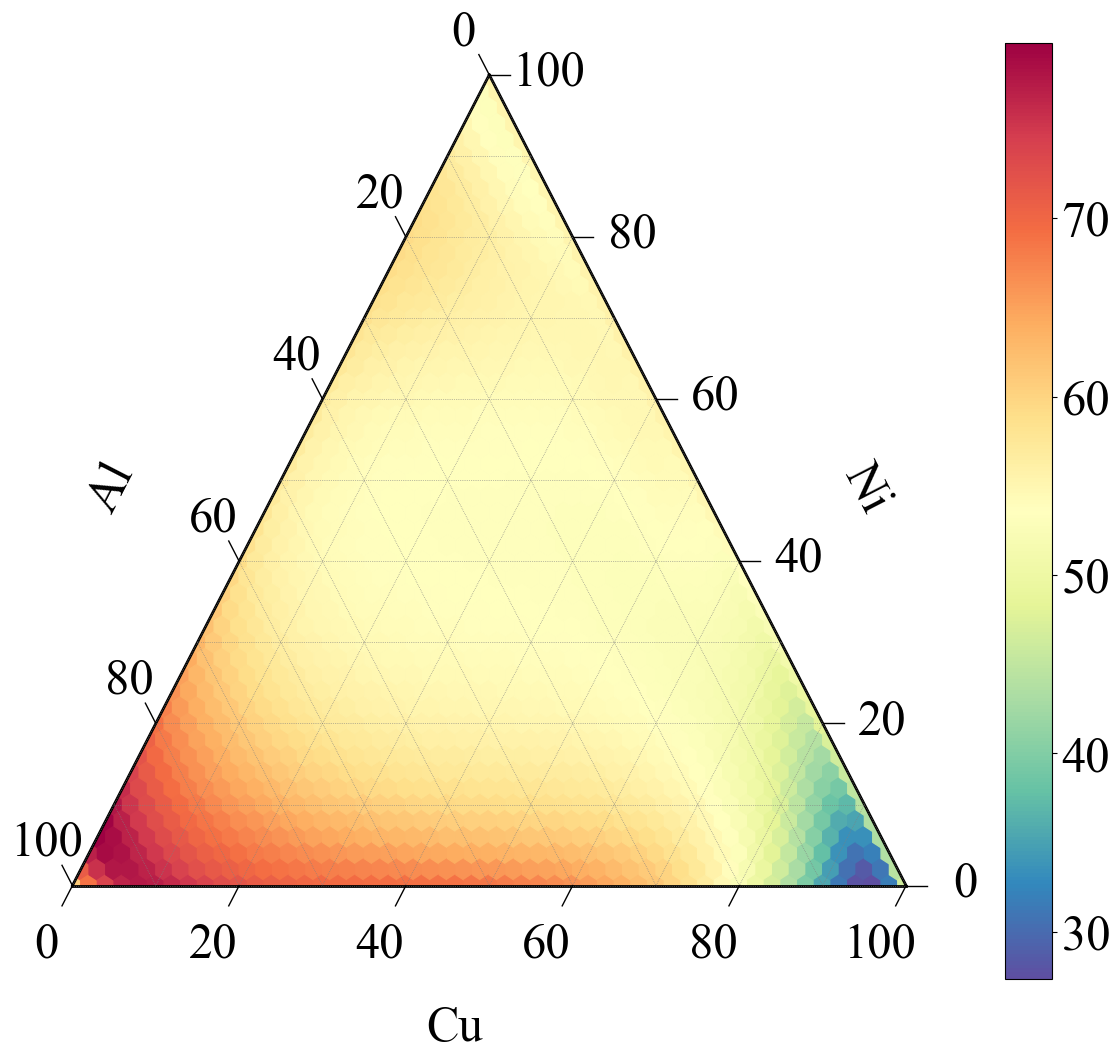

In [232]:
fig, tax = plot_ternary_heatmap(
    df=df_rand_split,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

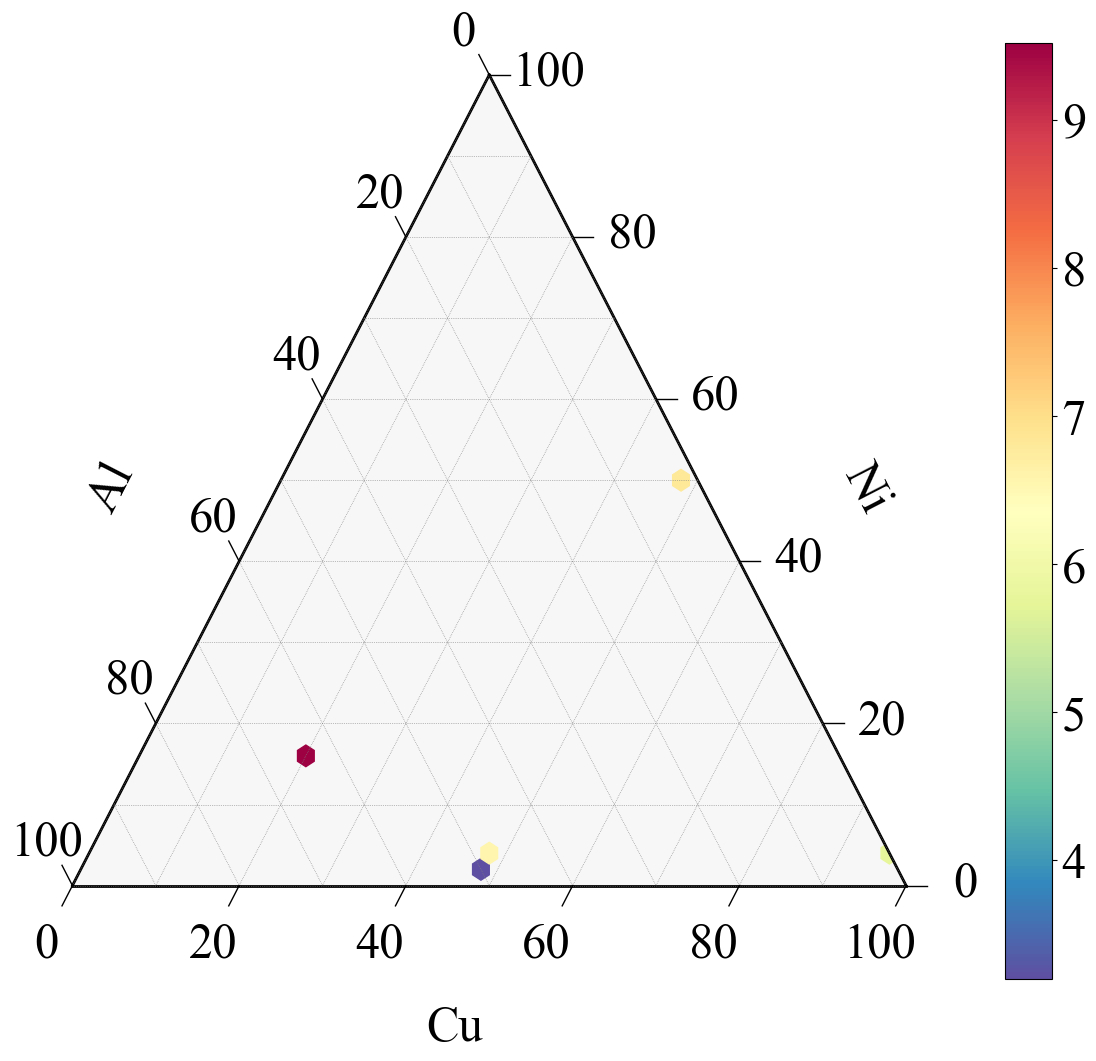

In [233]:
fig, tax = plot_ternary_heatmap(
    df=df_test_rand,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="y_error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

Experimental data GP - Kmeans splitting

In [287]:
feature_cols = ['VEC','del_EN','Cu','Ni','Al']
composition_cols = ['Cu','Ni','Al']

data_cluster = prepare_train_test_data(
    split_dict=cluster_split,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    standardize=True
)

In [288]:
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
)

gpr_nt_clus = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,   
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_nt_clus.fit(data_cluster["X_train_proc"], data_cluster["y_train"])
print("Learned kernel:", gpr_nt_clus.kernel_)

Learned kernel: 0.976**2 * Matern(length_scale=0.432, nu=2.5) + WhiteKernel(noise_level=0.2)


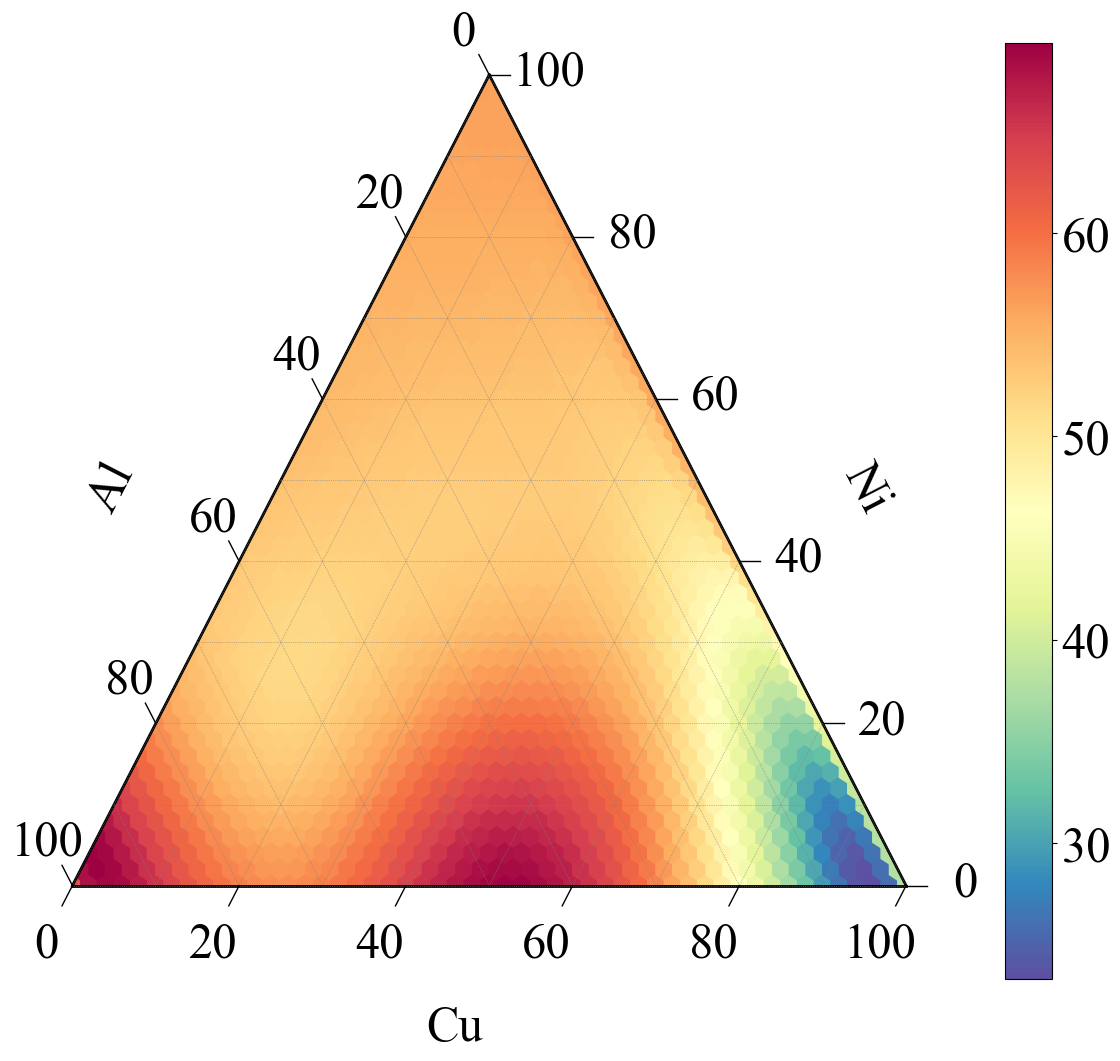

In [289]:

gp_cluster_split, df_cluster_split, df_test_clus = evaluate_and_predict_space(
    model=gpr_nt_clus,
    data_dict=data_cluster,
    comp_space=comp_space,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    return_std=True,
    save=True,
    save_path=PREDICTIONS_DIR / "GP-Experiments" / "gp_cluster_split.pkl",
    pred_col="e2"
)

fig, tax = plot_ternary_heatmap(
    df=df_cluster_split,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

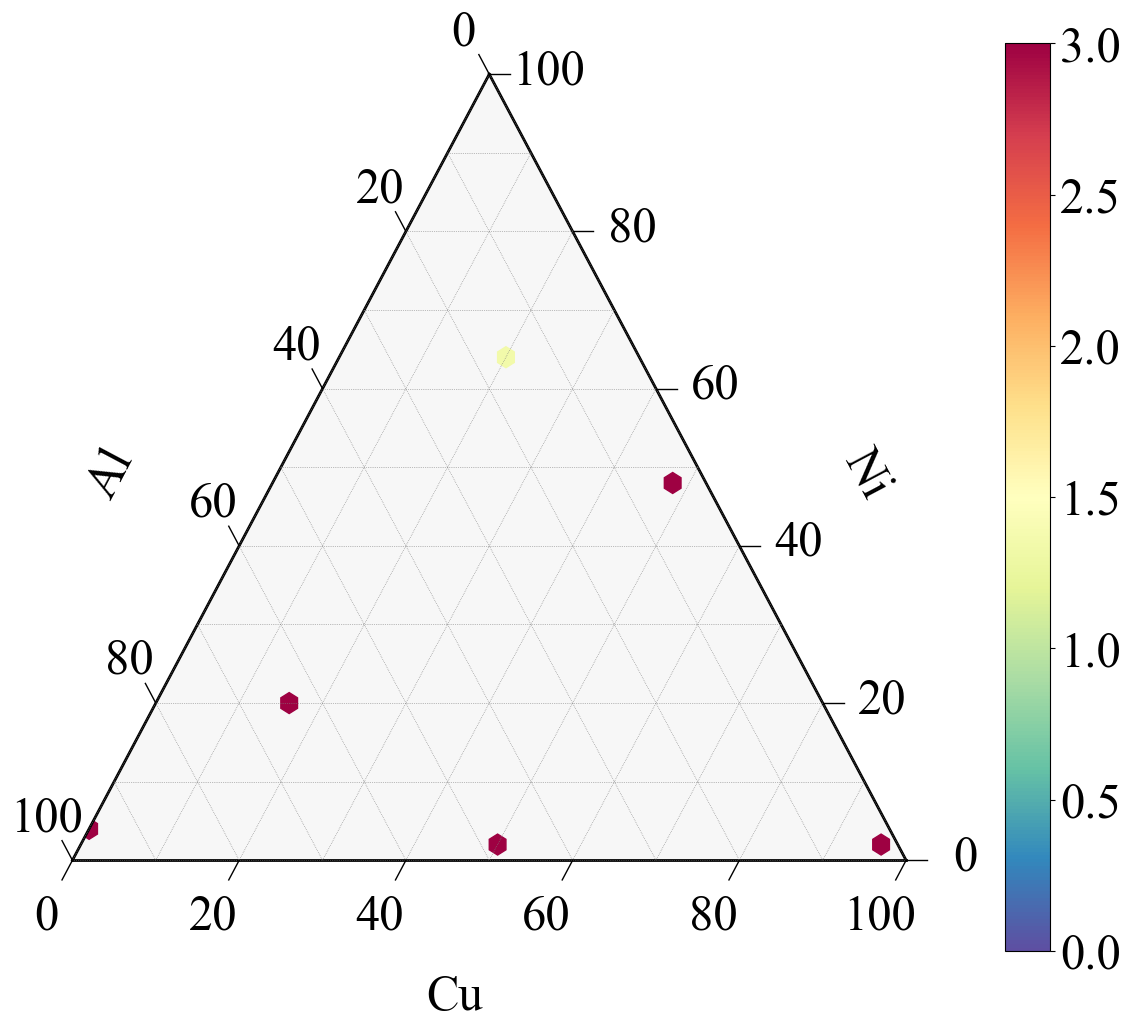

In [291]:
fig, tax = plot_ternary_heatmap(
    df=df_test_clus,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="y_error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=0,
    vmax=3,
    show=True,
    duplicate_handling="mean",
)

In [ ]:
e2_predict_GP_exp =  np.load(PREDICTIONS_DIR/"GP-Experiments/e2_predicted_GP.npy")

df_previous_split = pd.DataFrame(
    gp_cluster_split['x_space']*100,
    columns=[composition_cols+feature_cols]
)

df_previous_split["e2"] = e2_predict_GP_exp

fig, tax = plot_ternary_heatmap(
    df=df_previous_split,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

In [ ]:
e2_predict_GP_exp =  np.load(PREDICTIONS_DIR/"GP-Experiments/e2_predicted_GP.npy")

df_previous_split = pd.DataFrame(
    gp_cluster_split['x_space']*100,
    columns=feature_cols
)

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

df_test = data_cluster['X_test_df']
comp_cols = ["Cu", "Ni", "Al"]
df_test = df_test[['Cu','Ni','Al']]*100
df_test['y_test'] = data_cluster['y_test']



X_test = df_test[comp_cols].to_numpy(dtype=float)
X_big = df_previous_split[comp_cols].to_numpy(dtype=float)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_big)

distances, indices = nn.kneighbors(X_test)

distances = distances.ravel()
indices = indices.ravel()

matched = df_previous_split.iloc[indices].reset_index(drop=True)
df_compare = df_test.reset_index(drop=True).copy()

df_compare["e2_pred"] = matched["e2"].to_numpy()
df_compare["match_distance"] = distances
df_compare["error"] = df_compare["y_test"] - df_compare["e2_pred"]
df_compare["abs_error"] = np.abs(df_compare["error"])
df_compare["sq_error"] = df_compare["error"] ** 2

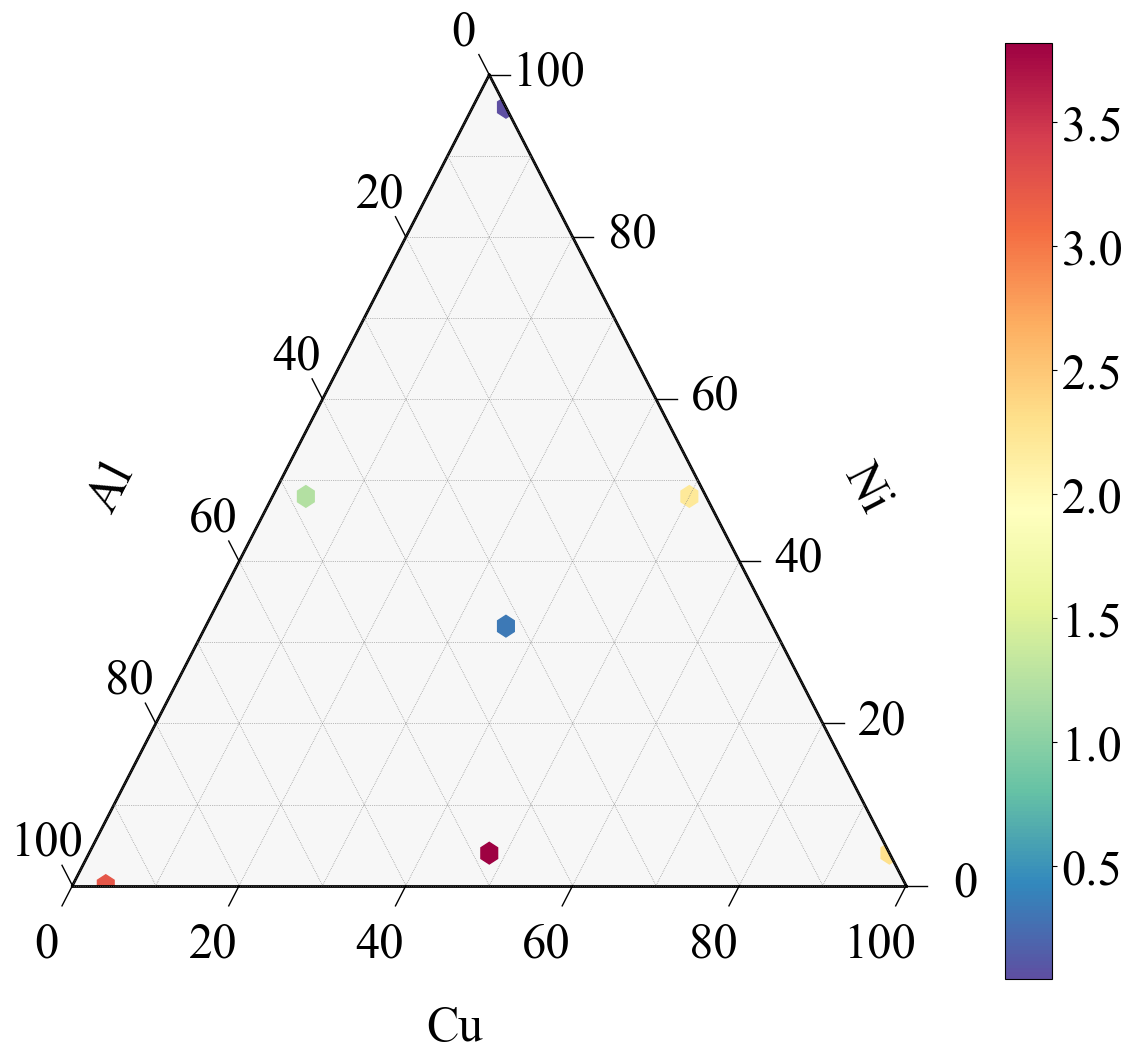

In [ ]:
fig, tax = plot_ternary_heatmap(
    df=df_compare,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="abs_error",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

Adaptive kernel approach

In [ ]:
# Source and target variables for Adaptive transfer kernel

def data_transfer_gp (X_source,X_target, y_source, y_target):
    # Convert to numpy
    Xs = np.asarray(X_source, dtype=float)
    Xt = np.asarray(X_target, dtype=float)
    
    # Add domain indicator ( 0 = source, 1 = target)
    Xs_aug = np.c_[Xs, np.zeros((len(Xs),1))]
    Xt_aug = np.c_[Xt, np.ones((len(Xt),1))]
    
    #combine datasets
    X_train = np.vstack([Xs_aug, Xt_aug])
    y_train = np.concatenate([y_source, y_target])
    
    return X_train,y_train

In [ ]:
feature_cols = ['VEC','del_EN']

data_cluster = prepare_train_test_data(
    split_dict=cluster_split,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    standardize=True
)

In [ ]:
feature_cols = ['VEC','del_EN']
composition_cols = ['Cu','Ni','Al']

elec_resis = np.load(PREDICTIONS_DIR/"ANN_Predictions/electrical_resistivity_predicted.npy")
tl_gp = comp_space.copy()
tl_gp['resistivity'] = elec_resis


X_source = tl_gp[feature_cols]
X_target = cluster_split['X_train_split'][feature_cols]
y_source = tl_gp['resistivity']
y_target = cluster_split["y_train"]


x_train,y_train = data_transfer_gp(X_source,X_target,y_source,y_target)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from models_scripts.AdaptiveTransferKernel import AdaptiveTransferKernel

kernel = AdaptiveTransferKernel(
    kernel=1.0 * Matern(length_scale=1.0, nu=2.5),
    lamb=2.0,
    lamb_bounds=(1.0, 3.0),
    different_noises=False,
)

gpr_pe = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-5,            # jitter for numerical stability
    normalize_y=True,      # y standardization inside sklearn
    n_restarts_optimizer=3 # increase later (5-10) if slow/unstable
)

gpr_pe.fit(x_train, y_train)
print("Learned kernel:", gpr_pe.kernel_)

Learned kernel: AdaptiveTransferKernel(0.00792, -11.5, 0.438)


/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:

feature_cols = ['VEC','del_EN']

data_cluster = prepare_train_test_data(
    split_dict=cluster_split,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    standardize=False
)
ones = np.ones(len(data_cluster['X_test_proc']))
data_cluster['X_test_proc'] = np.column_stack((data_cluster['X_test_proc'],ones))
data_cluster['X_train_split_full']["source"] = np.ones(len(data_cluster['X_train_split_full']))
data_cluster['X_test_split_full']["source"] = np.ones(len(data_cluster['X_test_split_full']))
comp_space["source"] = np.ones(len(comp_space))

feature_cols = ['VEC','del_EN','source']

gp_tl, df_tl_gp, df_test_tl = evaluate_and_predict_space(
    model=gpr_pe,
    data_dict=data_cluster,
    comp_space=comp_space,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    return_std=True,
    save=False,
    pred_col="e2"
)

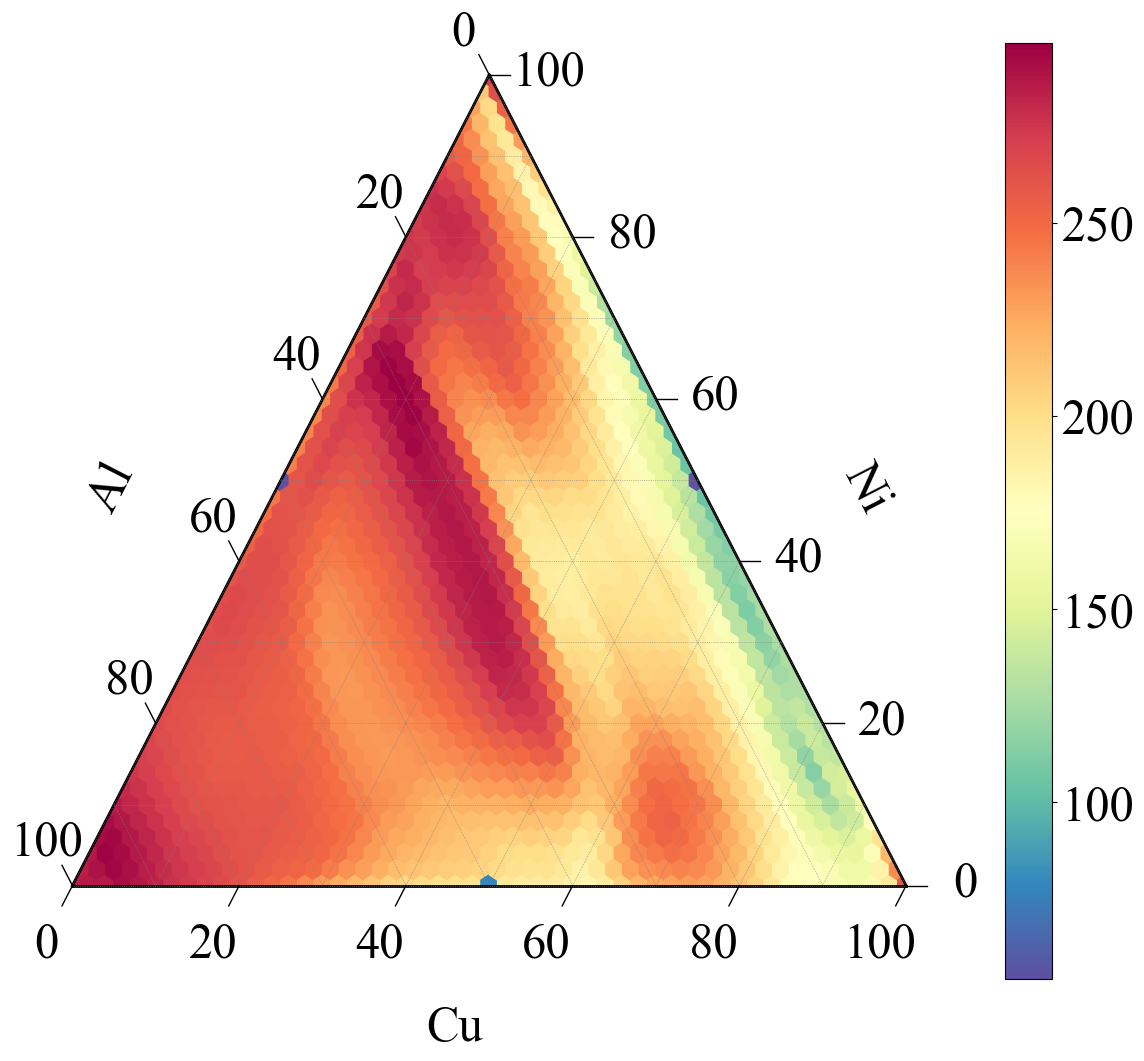

In [ ]:
fig, tax = plot_ternary_heatmap(
    df=df_tl_gp,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

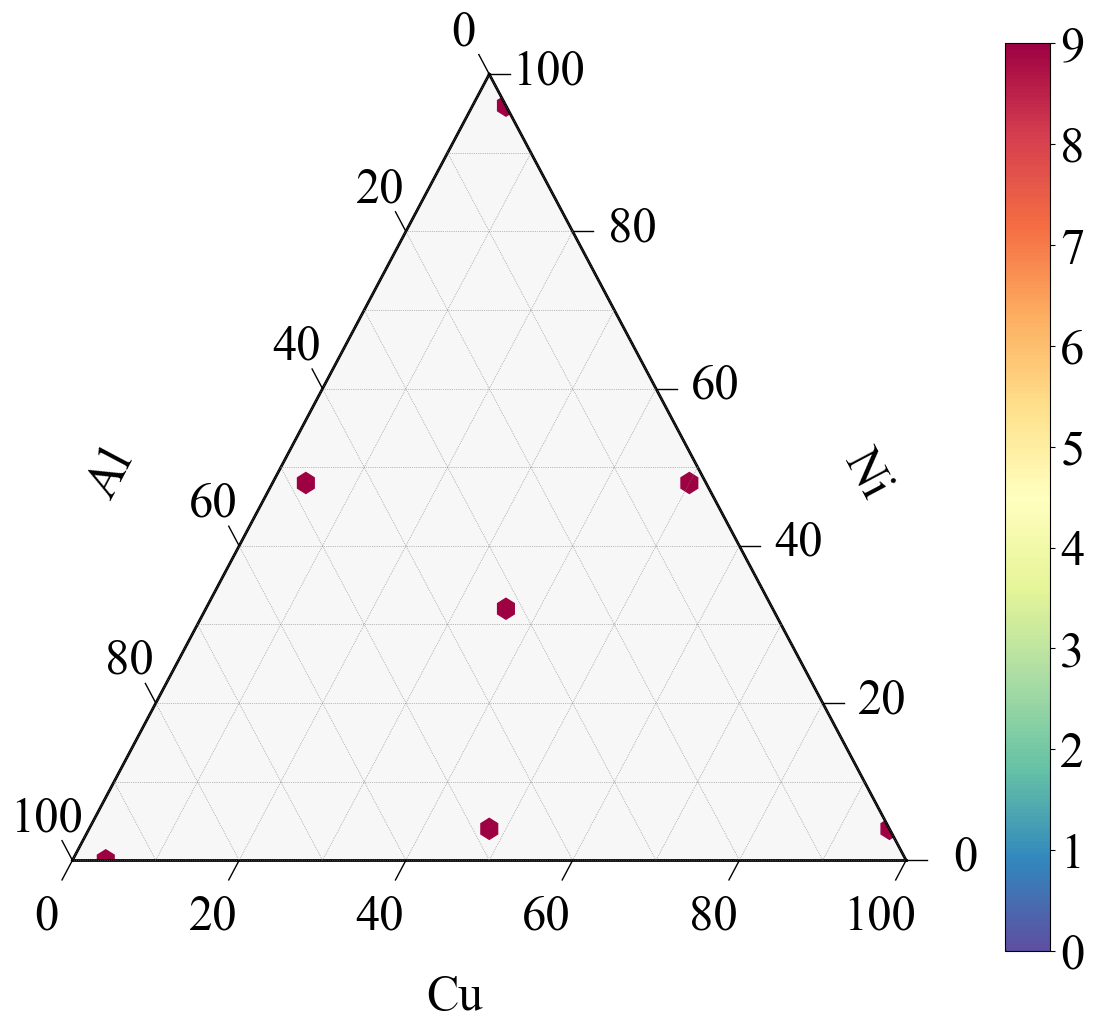

In [ ]:
fig, tax = plot_ternary_heatmap(
    df=df_test_tl,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="y_error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

In [339]:
import numpy as np
import pandas as pd
import copy

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, WhiteKernel


def build_gp_model():
    kernel = (
        C(1.0, (1e-3, 1e3)) *
        Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
    )

    model = GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.0,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=None
    )
    return model


def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse,
        "mse": mean_squared_error(y_true, y_pred),
    }


def repeated_split_model_selection(
    X, y,
    n_splits=100,
    test_size=0.15,
    random_seed=42,
    selection_metric="rmse",
    maximize_metric=False
):

    rng = np.random.default_rng(random_seed)

    results = []
    best_model = None
    best_score = -np.inf if maximize_metric else np.inf

    best_split_data = None

    for i in range(n_splits):

        split_seed = int(rng.integers(0, 1_000_000))

        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=test_size, random_state=split_seed
        )

        model = build_gp_model()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        metrics = evaluate_regression(y_val, y_pred)
        score = metrics[selection_metric]

        results.append({
            "split": i,
            "seed": split_seed,
            **metrics,
            "kernel": str(model.kernel_)
        })

        is_better = score > best_score if maximize_metric else score < best_score

        if is_better:
            best_score = score
            best_model = copy.deepcopy(model)

            best_split_data = {
                "split": i,
                "seed": split_seed,
                "train_indices": X_train.index,
                "test_indices": X_val.index
            }

    results_df = pd.DataFrame(results).sort_values(
        selection_metric,
        ascending=not maximize_metric
    )

    return best_model, best_split_data, results_df

In [303]:
data_cluster['X_test_proc'].shape

(6, 5)

In [340]:
x_before = np.vstack((data_cluster['X_train_proc'],data_cluster['X_test_proc']))
y_before = np.hstack((data_cluster['y_train'],data_cluster['y_test']))

In [356]:
X = pd.DataFrame(x_before,columns=feature_cols)
y = pd.DataFrame(y_before)

best_model, best_split, results = repeated_split_model_selection(
    X,
    y,
    n_splits=200,
    test_size=0.22,
    selection_metric="rmse",
    maximize_metric=False
)

In [357]:
X_train = X.loc[best_split['train_indices']]
y_train = y.loc[best_split['train_indices']]

X_test = X.loc[best_split['test_indices']]
y_test = y.loc[best_split['test_indices']]

In [359]:
data_smart_split = {}
data_smart_split['scaler'] = data_cluster['scaler']
data_smart_split['X_test_split_full'] = X_test
data_smart_split['X_test_proc'] = X_test
data_smart_split['y_test'] = y_test
data_smart_split['standardize'] = data_cluster['standardize']

/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(


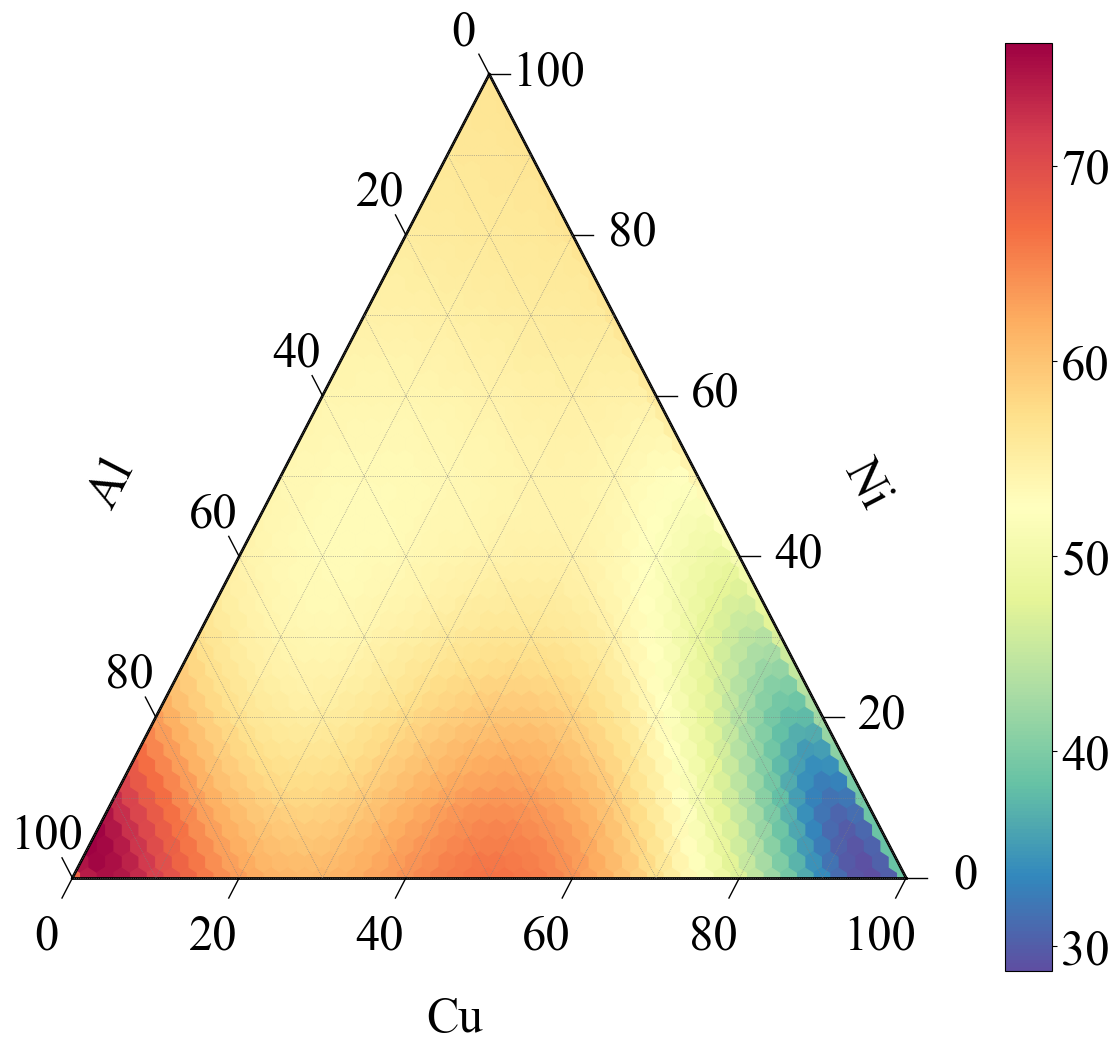

In [360]:
gp_cluster_split, df_cluster_split, df_test_clus = evaluate_and_predict_space(
    model=best_model,
    data_dict=data_smart_split,
    comp_space=comp_space,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    return_std=True,
    save=False,
    pred_col="e2"
)

fig, tax = plot_ternary_heatmap(
    df=df_cluster_split,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

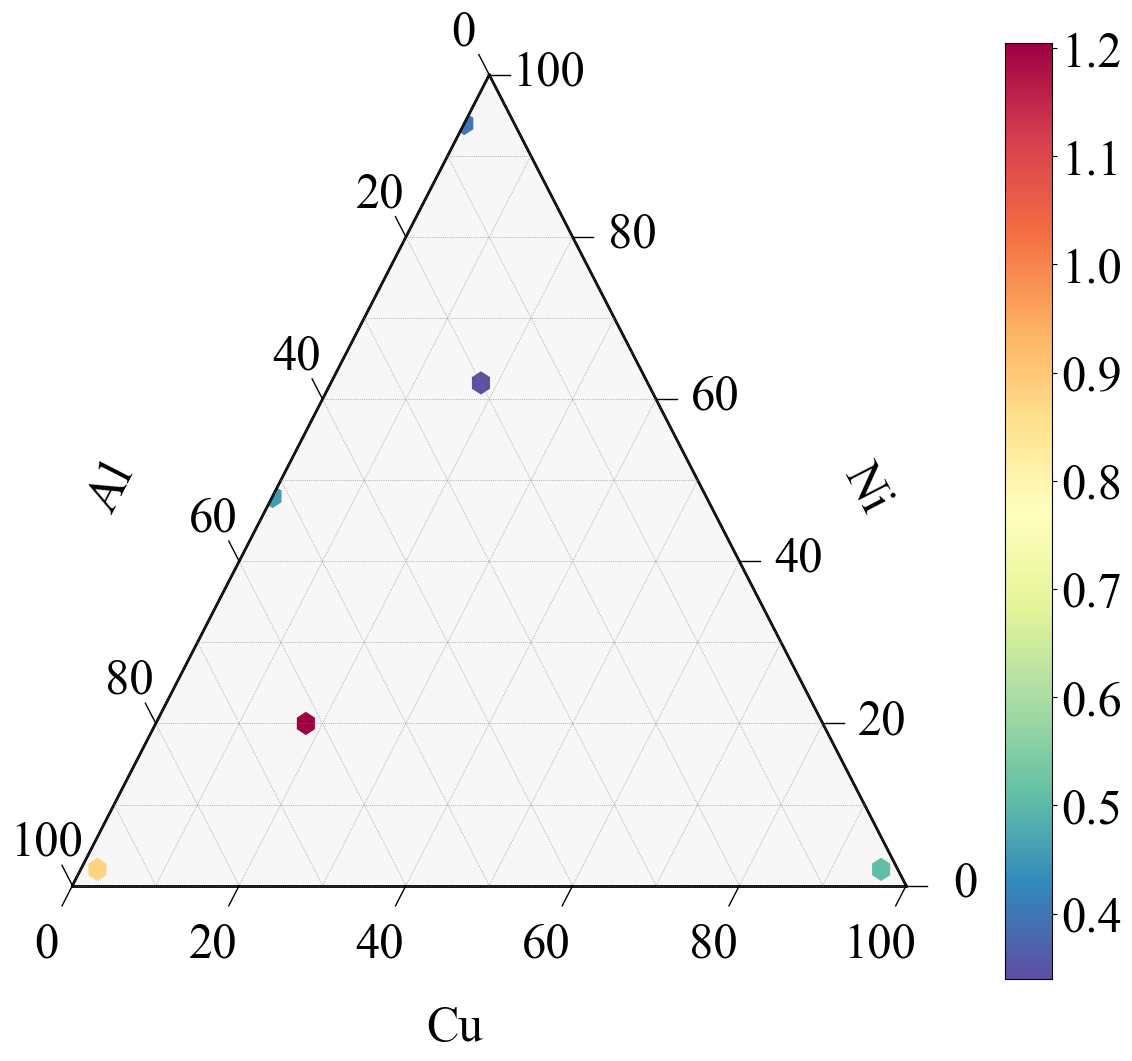

In [361]:
fig, tax = plot_ternary_heatmap(
    df=df_test_clus,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="y_error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)